# PulseFlow — Notebook Final de Investigação
### Nano-Challenge: Spotify Data | CBL aplicado à análise de dados

**Challenge statement:** gerar insights a partir do Spotify Dataset e transformar esses resultados em recomendações baseadas em evidências para o PulseFlow.

O projeto investiga se características musicais podem apoiar uma experiência de reprodução mais adequada ao **contexto atual do usuário**, sem confundir padrões do dataset com preferência humana comprovada.

> **Regra metodológica central:** `track_genre` é utilizado como *proxy* exploratório de contexto em parte das análises. O Spotify Dataset não contém rótulos reais de “Treino”, “Estudo”, “Relaxamento” ou “Trabalho” definidos por usuários.


## 1. Introdução e problema

O PulseFlow parte do problema de **Context Switching**: uma pessoa muda de atividade, mas o conteúdo em reprodução pode continuar refletindo o contexto anterior.

A investigação busca responder quais dados e características musicais podem apoiar uma adaptação contextual e quais partes da proposta ainda dependem de validação com usuários.


## 2. Objetivo de negócio

**Objetivo:** aumentar a adequação da experiência musical ao contexto atual do usuário e reduzir o esforço/interações necessários para encontrar ou trocar para um conteúdo apropriado.

**Métricas de negócio candidatas:**
- percentual de recomendações consideradas adequadas ao contexto;
- preferência por recomendação contextual versus seleção aleatória;
- número de skips/rejeições;
- tempo ou número de interações até encontrar conteúdo adequado.

Nesta versão do notebook, as métricas de percepção do usuário ainda dependem da conclusão da pesquisa e do experimento de recomendação.


## 3. Objetivo de Machine Learning e métrica

**Objetivo de ML:** classificar músicas por sua adequação a contextos iniciais, usando características sonoras do Spotify Dataset.

Nesta prova inicial são usados três **rótulos-proxy**:
- Treino;
- Estudo;
- Relaxamento.

**Métrica principal:** **Macro F1**, pois o problema possui classes desbalanceadas e é importante avaliar o desempenho em todas elas.

A classificação por proxy é uma prova técnica inicial. A adequação real ao contexto precisa ser validada com usuários.


## 4. Escopo — TRATA / NÃO TRATA

### TRATA
- recomendação/adaptação musical contextual;
- características musicais do Spotify Dataset;
- contextos definidos pelo usuário;
- preferências declaradas ou aprendidas;
- classificação exploratória de Treino, Estudo e Relaxamento;
- futura personalização de Trabalho a partir da pesquisa.

### NÃO TRATA nesta etapa
- diagnóstico médico ou inferência clínica;
- automação clínica;
- monitoramento contínuo real por smartwatch;
- detecção automática de conversa em produção;
- integração comercial completa com serviços de streaming;
- funcionamento autônomo em contextos críticos sem confirmação.


## 5. Guiding Questions e hipóteses

### Guiding Questions oficiais

| GQ | Pergunta | Situação nesta versão |
|---|---|---|
| **GQ1 — Dados** | Quais características musicais melhor diferenciam músicas adequadas para Treino, Estudo, Relaxamento e Trabalho? | Parcialmente respondida com Spotify Dataset |
| **GQ2 — Usuário** | As preferências musicais de uma mesma pessoa mudam conforme a atividade? | Depende da pesquisa |
| **GQ3 — Trabalho** | O perfil musical adequado para trabalho varia conforme o tipo de trabalho? | Depende da pesquisa |
| **GQ4 — Smartwatch** | Atividade e sinais de smartwatch podem ajudar a decidir mudanças de intensidade musical? | Visão futura |
| **GQ5 — Machine Learning** | Um modelo baseado nas características musicais consegue superar uma seleção simples/aleatória? | Parcialmente respondida com proxy |
| **GQ6 — Ética** | Quais dados pessoais/contextuais são realmente necessários sem coleta invasiva? | Tratada conceitualmente no escopo/ética |

### Hipóteses

| Hipótese | Formulação |
|---|---|
| **H1 — Treino** | Maior `energy`, `tempo` e/ou `danceability`. |
| **H2 — Estudo** | Menor `speechiness` e maior `instrumentalness`. |
| **H3 — Relaxamento** | Menor `energy` e `tempo`, maior `acousticness`. |
| **H4 — Contexto** | A preferência do mesmo usuário muda conforme a atividade. |
| **H5 — Trabalho** | O perfil adequado varia conforme o tipo de trabalho. |
| **H6 — Recomendação** | Características musicais + contexto podem superar seleção aleatória em adequação percebida. |

H1–H3 são testadas com proxies do dataset. H4–H6 exigem evidência adicional de usuários/produto.


In [1]:
# Instalação automática das dependências do projeto
# Se as bibliotecas já estiverem instaladas, esta célula não reinstala nada.

import sys
import subprocess
import importlib.util

DEPENDENCIAS = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "scipy": "scipy",
    "sklearn": "scikit-learn",
}

faltando = [
    pacote_pip
    for modulo, pacote_pip in DEPENDENCIAS.items()
    if importlib.util.find_spec(modulo) is None
]

if faltando:
    print("Bibliotecas ausentes:", ", ".join(faltando))
    print("Instalando automaticamente...")

    try:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", *faltando]
        )
        print("Instalação concluída.")
    except Exception as erro:
        raise RuntimeError(
            "Não foi possível instalar automaticamente as bibliotecas. "
            "Execute no terminal:\n\n"
            f'"{sys.executable}" -m pip install pandas numpy matplotlib seaborn scipy\n\n'
            "Depois reinicie o kernel do Jupyter e execute o notebook novamente."
        ) from erro
else:
    print("Todas as bibliotecas necessárias já estão instaladas.")

# Imports do projeto
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

print("Dependências carregadas com sucesso.")
print("pandas:", pd.__version__)
print("numpy:", np.__version__)


Todas as bibliotecas necessárias já estão instaladas.


Dependências carregadas com sucesso.
pandas: 2.2.3
numpy: 2.3.5


## 6. Fonte e descrição dos dados

**Origem:** Spotify Dataset fornecido no Nano-Challenge.

O CSV permanece **externo ao notebook**. Coloque `dataset.csv` ou `dataset-1.csv` na mesma pasta do `.ipynb`.

O dataset original possui 114.000 registros, 21 colunas e 114 gêneros musicais.

> A licença/origem definitiva deve ser citada conforme o material oficial da disciplina/dataset utilizado.


In [2]:
# Carregamento do dataset externo
# Coloque o arquivo CSV na mesma pasta deste notebook.
#
# Nomes aceitos:
# - dataset.csv
# - dataset-1.csv
# - dataset(in).csv
# (qualquer "dataset*.csv" tambem serve, via fallback abaixo)

from pathlib import Path

candidatos = [
    Path("dataset.csv"),
    Path("dataset-1.csv"),
    Path("dataset(in).csv"),
]

# Fallback: qualquer arquivo dataset*.csv na pasta do notebook.
candidatos += sorted(Path(".").glob("dataset*.csv"))

DATA_PATH = next((p for p in candidatos if p.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Dataset não encontrado.\n\n"
        "Coloque o arquivo 'dataset.csv' ou 'dataset-1.csv' "
        "na mesma pasta do notebook e execute novamente."
    )

df_raw = pd.read_csv(DATA_PATH)

# Validação básica
assert df_raw.shape[1] == 21, (
    f"Número inesperado de colunas: {df_raw.shape[1]}. Esperado: 21."
)
assert "track_id" in df_raw.columns
assert "track_genre" in df_raw.columns

print(f"Dataset carregado: {DATA_PATH}")
print("Shape:", df_raw.shape)

df_raw.head(3)


Dataset carregado: dataset-1.csv
Shape: (114000, 21)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,1,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,0,-9.734,1,0.0557,0.2100,0.000000,0.117,0.120,76.332,4,acoustic


In [3]:
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [4]:
print("Colunas:", df_raw.columns.tolist())
print()
print("Gêneros únicos:", df_raw['track_genre'].nunique())
print("Faixas por gênero (esperado 1000 cada):")
print(df_raw['track_genre'].value_counts().describe())


Colunas: ['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']

Gêneros únicos: 114
Faixas por gênero (esperado 1000 cada):
count     114.0
mean     1000.0
std         0.0
min      1000.0
25%      1000.0
50%      1000.0
75%      1000.0
max      1000.0
Name: count, dtype: float64


## 7. Limpeza e preparação

A preparação é reproduzível a partir do CSV original.

Etapas:
1. inspecionar valores ausentes;
2. analisar `track_id` repetida sem remover automaticamente faixas multigênero;
3. remover `Unnamed: 0`;
4. remover registros com campos essenciais ausentes;
5. remover apenas linhas completamente idênticas;
6. validar ranges e integridade do resultado.


In [5]:
# 4.1 — Nulos
nulos = df_raw.isna().sum()
nulos = nulos[nulos > 0]
print("Colunas com valores ausentes:")
print(nulos)
print()
print("Linhas afetadas:")
display(df_raw[df_raw.isna().any(axis=1)])


Colunas com valores ausentes:
artists       1
album_name    1
track_name    1
dtype: int64

Linhas afetadas:


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65900,65900,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,NaN,0,0,False,0.501,0.583,7,-9.46,0,0.0605,0.69,0.00396,0.0747,0.734,138.391,4,k-pop


In [6]:
# 4.2 — Duplicatas por track_id
dup_track = df_raw['track_id'].duplicated().sum()
print(f"Registros além da 1ª ocorrência do track_id: {dup_track}")

# Duplicatas de linha inteira (todas as colunas, exceto o índice Unnamed: 0)
cols_sem_indice = [c for c in df_raw.columns if c != 'Unnamed: 0']
dup_linha_completa = df_raw.duplicated(subset=cols_sem_indice).sum()
print(f"Linhas 100% duplicadas (mesma faixa, mesmo gênero, todos os campos iguais): {dup_linha_completa}")

# Exemplo: uma mesma track_id aparecendo em vários gêneros
exemplo_id = df_raw['track_id'].value_counts().idxmax()
print(f"\nExemplo — track_id '{exemplo_id}' aparece em {df_raw['track_id'].value_counts().max()} gêneros diferentes:")
display(df_raw[df_raw['track_id'] == exemplo_id][['track_id','track_name','artists','track_genre']])


Registros além da 1ª ocorrência do track_id: 24259


Linhas 100% duplicadas (mesma faixa, mesmo gênero, todos os campos iguais): 450



Exemplo — track_id '6S3JlDAGk3uu3NtZbPnuhS' aparece em 9 gêneros diferentes:


,track_id,track_name,artists,track_genre
8315,6S3JlDAGk3uu3NtZbPnuhS,Baby Blue - Remastered 2010,Badfinger,blues
19759,6S3JlDAGk3uu3NtZbPnuhS,Baby Blue - Remastered 2010,Badfinger,country
34728,6S3JlDAGk3uu3NtZbPnuhS,Baby Blue - Remastered 2010,Badfinger,folk
62226,6S3JlDAGk3uu3NtZbPnuhS,Baby Blue - Remastered 2010,Badfinger,j-pop
63087,6S3JlDAGk3uu3NtZbPnuhS,Baby Blue - Remastered 2010,Badfinger,j-rock
82064,6S3JlDAGk3uu3NtZbPnuhS,Baby Blue - Remastered 2010,Badfinger,power-pop
84129,6S3JlDAGk3uu3NtZbPnuhS,Baby Blue - Remastered 2010,Badfinger,psych-rock
99727,6S3JlDAGk3uu3NtZbPnuhS,Baby Blue - Remastered 2010,Badfinger,singer-songwriter
102732,6S3JlDAGk3uu3NtZbPnuhS,Baby Blue - Remastered 2010,Badfinger,songwriter


In [7]:
# 4.3 — Decisão de limpeza
#
# A mesma track_id aparecer em vários gêneros NÃO é necessariamente erro:
# uma faixa pode estar associada a mais de um gênero. Por isso, NÃO removemos
# duplicatas apenas por track_id.
#
# Removemos somente:
# 1) a coluna de índice sem valor analítico (Unnamed: 0);
# 2) registros sem campos textuais essenciais;
# 3) linhas completamente idênticas após a remoção do índice.

# Criamos uma cópia do dataset original
df = df_raw.copy()
linhas_iniciais = len(df)

# 1. Remover coluna de índice sem valor analítico
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# 2. Remover registros sem informações textuais essenciais
campos_essenciais = ['artists', 'album_name', 'track_name']
nulos_antes = df[campos_essenciais].isna().any(axis=1).sum()
df = df.dropna(subset=campos_essenciais)

# 3. Remover duplicatas completas
# Importante: não usamos subset=['track_id'], pois isso eliminaria
# ocorrências legítimas da mesma faixa associada a gêneros diferentes.
duplicatas_completas = df.duplicated().sum()
df = df.drop_duplicates()

# 4. Resetar índice
df = df.reset_index(drop=True)

# Resumo da limpeza
print("=== RESUMO DA LIMPEZA ===")
print(f"Linhas originais: {linhas_iniciais}")
print(f"Linhas removidas por dados ausentes: {nulos_antes}")
print(f"Duplicatas completas removidas: {duplicatas_completas}")
print(f"Linhas finais: {len(df)}")
print(f"Colunas finais: {df.shape[1]}")
print(f"Shape final: {df.shape}")


=== RESUMO DA LIMPEZA ===
Linhas originais: 114000
Linhas removidas por dados ausentes: 1
Duplicatas completas removidas: 450
Linhas finais: 113549
Colunas finais: 20
Shape final: (113549, 20)


In [8]:
# 4.4 — Validação da limpeza

print("=== VALIDAÇÃO PÓS-LIMPEZA ===")

# Coluna de índice removida
assert 'Unnamed: 0' not in df.columns
print("✓ Coluna 'Unnamed: 0' removida")

# Sem nulos nos campos essenciais
assert df[['artists', 'album_name', 'track_name']].isna().sum().sum() == 0
print("✓ Nenhum nulo nos campos essenciais")

# Sem duplicatas completas
assert df.duplicated().sum() == 0
print("✓ Nenhuma duplicata completa")

# track_id deve existir e não pode estar ausente
assert df['track_id'].notna().all()
print("✓ Nenhum track_id ausente")

# Track IDs repetidos podem continuar existindo quando a mesma faixa
# aparece legitimamente associada a gêneros diferentes.
track_ids_repetidos = df['track_id'].duplicated().sum()
print(
    f"✓ Registros além da primeira ocorrência de track_id mantidos quando aplicável: "
    f"{track_ids_repetidos}"
)

print("\nLimpeza validada com sucesso.")


=== VALIDAÇÃO PÓS-LIMPEZA ===
✓ Coluna 'Unnamed: 0' removida
✓ Nenhum nulo nos campos essenciais
✓ Nenhuma duplicata completa
✓ Nenhum track_id ausente
✓ Registros além da primeira ocorrência de track_id mantidos quando aplicável: 23809

Limpeza validada com sucesso.


In [9]:
# 4.5 — Validação de ranges (features que deveriam estar entre 0 e 1)
features_01 = [
    'danceability', 'energy', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'valence'
]

range_check = df[features_01].agg(['min', 'max']).T
print(range_check)

assert (
    (range_check['min'] >= 0).all()
    and (range_check['max'] <= 1).all()
), "Range fora do esperado!"

print("\nOK — todas as features 0–1 estão dentro do range esperado.")


                  min    max
danceability      0.0  0.985
energy            0.0  1.000
speechiness       0.0  0.965
acousticness      0.0  0.996
instrumentalness  0.0  1.000
liveness          0.0  1.000
valence           0.0  0.995

OK — todas as features 0–1 estão dentro do range esperado.


## 8. EDA — Análise Exploratória

A EDA examina distribuições, correlações e diferenças entre grupos-proxy para identificar características úteis à GQ1 e preparar os testes de H1–H3.


### 8.1 Distribuições das features sonoras

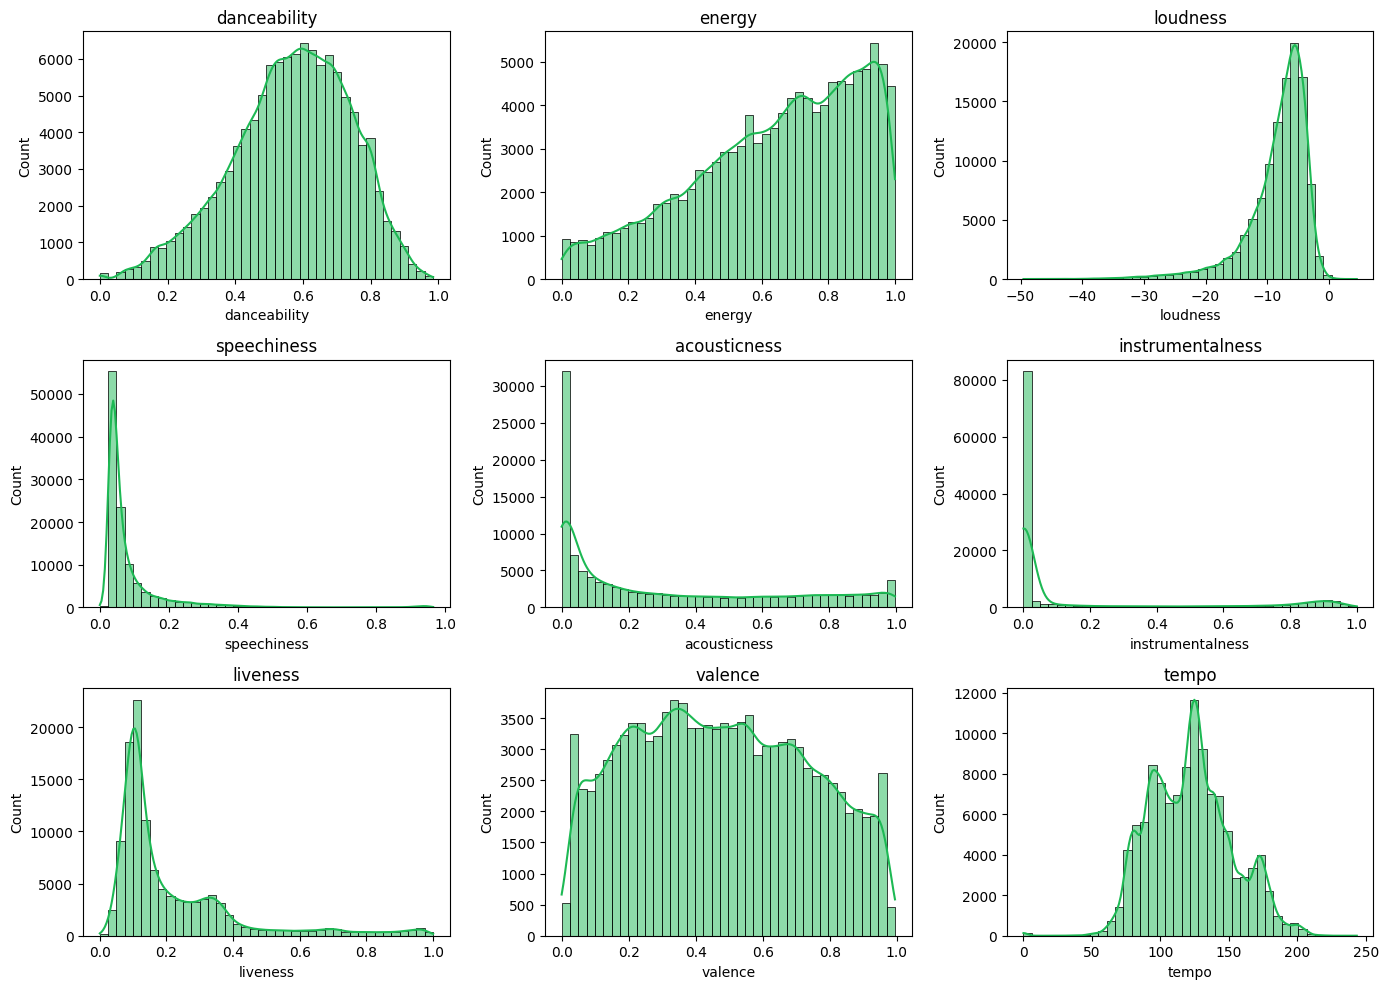

In [10]:
feats = ['danceability','energy','loudness','speechiness','acousticness',
         'instrumentalness','liveness','valence','tempo']

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, f in zip(axes.flat, feats):
    sns.histplot(df[f], bins=40, kde=True, ax=ax, color="#1DB954")
    ax.set_title(f)
plt.tight_layout()
plt.savefig("fig_distribuicoes.png", dpi=110)
plt.show()


### 8.2 Correlação entre as features

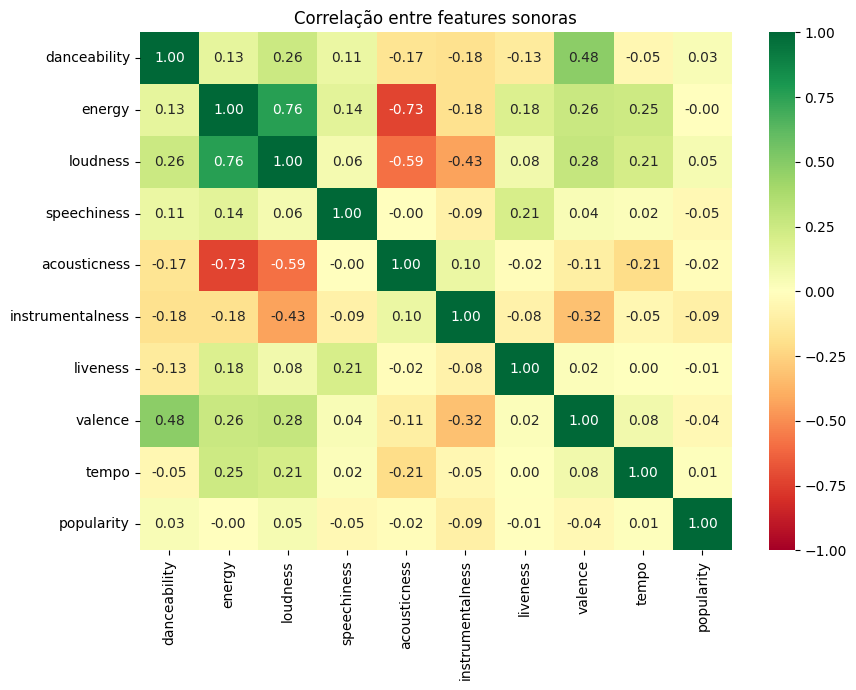

In [11]:
corr = df[feats + ['popularity']].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0, vmin=-1, vmax=1)
plt.title("Correlação entre features sonoras")
plt.tight_layout()
plt.savefig("fig_correlacao.png", dpi=110)
plt.show()


### 8.3 Grupos-proxy de contexto

- **Treino:** `edm`, `techno`, `hardstyle`, `dance`, `party`
- **Estudo:** `study`
- **Relaxamento:** `sleep`

Essas escolhas são aproximações exploratórias e não rótulos humanos.


In [12]:
grupo_estudo = df[df['track_genre'] == 'study']
grupo_relax = df[df['track_genre'] == 'sleep']
grupo_treino = df[df['track_genre'].isin(['edm','techno','hardstyle','dance','party'])]
grupo_resto = df[~df['track_genre'].isin(['study','sleep','edm','techno','hardstyle','dance','party'])]

print("Tamanho dos grupos:")
print("study:", len(grupo_estudo))
print("sleep:", len(grupo_relax))
print("treino (proxy):", len(grupo_treino))
print("resto:", len(grupo_resto))


Tamanho dos grupos:
study: 998
sleep: 1000
treino (proxy): 4950
resto: 106601


### 8.4 H1 — Treino

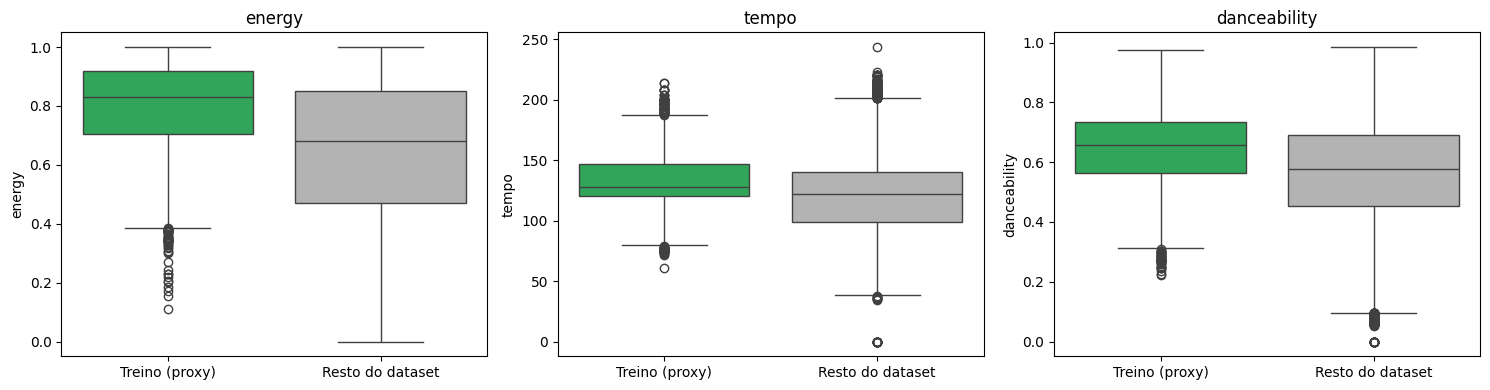

H1 [energy] — Mann-Whitney U (treino > resto): estatística=362046844.5, p-valor=0.00e+00
H1 [tempo] — Mann-Whitney U (treino > resto): estatística=312458705.5, p-valor=4.05e-107
H1 [danceability] — Mann-Whitney U (treino > resto): estatística=336408247.0, p-valor=8.81e-236


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, f in zip(axes, ['energy','tempo','danceability']):
    sns.boxplot(data=pd.concat([
        grupo_treino.assign(grupo='Treino (proxy)'),
        grupo_resto.assign(grupo='Resto do dataset')
    ]), x='grupo', y=f, hue='grupo', ax=ax, palette=["#1DB954","#B3B3B3"], legend=False)
    ax.set_title(f)
    ax.set_xlabel("")
plt.tight_layout()
plt.savefig("fig_h1_treino.png", dpi=110)
plt.show()

for f in ['energy','tempo','danceability']:
    t, p = stats.mannwhitneyu(grupo_treino[f], grupo_resto[f], alternative='greater')
    print(f"H1 [{f}] — Mann-Whitney U (treino > resto): estatística={t:.1f}, p-valor={p:.2e}")


### 8.5 H2 — Estudo

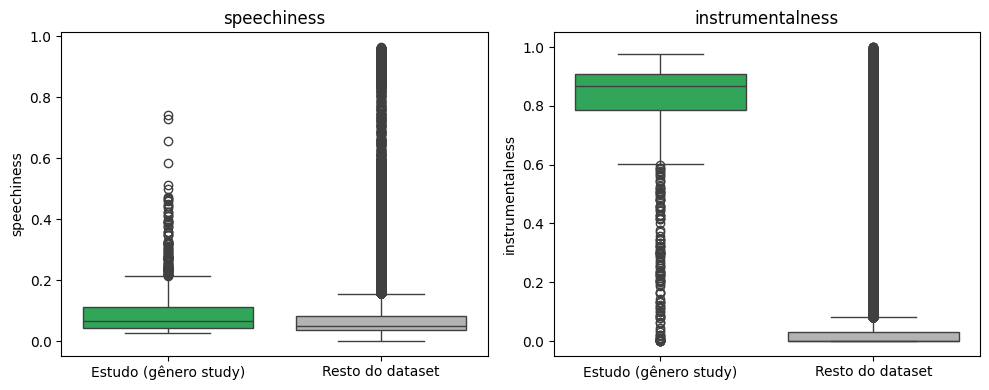

H2 [speechiness menor] — p-valor=1.00e+00
H2 [instrumentalness maior] — p-valor=0.00e+00


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, f in zip(axes, ['speechiness','instrumentalness']):
    sns.boxplot(data=pd.concat([
        grupo_estudo.assign(grupo='Estudo (gênero study)'),
        grupo_resto.assign(grupo='Resto do dataset')
    ]), x='grupo', y=f, hue='grupo', ax=ax, palette=["#1DB954","#B3B3B3"], legend=False)
    ax.set_title(f)
    ax.set_xlabel("")
plt.tight_layout()
plt.savefig("fig_h2_estudo.png", dpi=110)
plt.show()

t, p = stats.mannwhitneyu(grupo_estudo['speechiness'], grupo_resto['speechiness'], alternative='less')
print(f"H2 [speechiness menor] — p-valor={p:.2e}")
t, p = stats.mannwhitneyu(grupo_estudo['instrumentalness'], grupo_resto['instrumentalness'], alternative='greater')
print(f"H2 [instrumentalness maior] — p-valor={p:.2e}")


### 8.6 H3 — Relaxamento

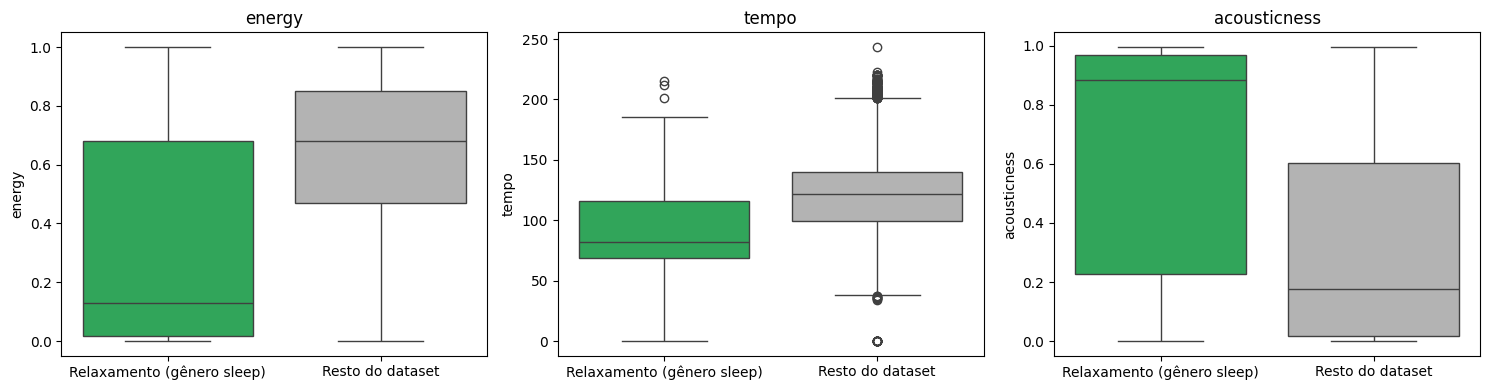

H3 [energy menor] — p-valor=5.20e-131
H3 [tempo menor] — p-valor=5.14e-181
H3 [acousticness maior] — p-valor=2.72e-156


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, f in zip(axes, ['energy','tempo','acousticness']):
    sns.boxplot(data=pd.concat([
        grupo_relax.assign(grupo='Relaxamento (gênero sleep)'),
        grupo_resto.assign(grupo='Resto do dataset')
    ]), x='grupo', y=f, hue='grupo', ax=ax, palette=["#1DB954","#B3B3B3"], legend=False)
    ax.set_title(f)
    ax.set_xlabel("")
plt.tight_layout()
plt.savefig("fig_h3_relax.png", dpi=110)
plt.show()

t, p = stats.mannwhitneyu(grupo_relax['energy'], grupo_resto['energy'], alternative='less')
print(f"H3 [energy menor] — p-valor={p:.2e}")
t, p = stats.mannwhitneyu(grupo_relax['tempo'], grupo_resto['tempo'], alternative='less')
print(f"H3 [tempo menor] — p-valor={p:.2e}")
t, p = stats.mannwhitneyu(grupo_relax['acousticness'], grupo_resto['acousticness'], alternative='greater')
print(f"H3 [acousticness maior] — p-valor={p:.2e}")


### 8.7 Painel visual do Context Engine (modos operacionais)

Mapeia os gêneros do dataset para os modos operacionais do PulseFlow, deriva dois índices heurísticos (CDI e ACS), aplica hard filters por modo e consolida tudo em um painel de 4 quadrantes.

In [ ]:
# 8.7 — PulseFlow Context Engine: painel visual dos dados tratados
# 1. Mapeamento de Modos e Submodos Operacionais do PulseFlow
mode_genre_mapping = {
    'Treino': [
        'dance',
        'edm',
        'drum-and-bass',
        'electro',
        'hardstyle',
        'party',
        'techno',
        'trance',
        'progressive-house',
        'club',
        'breakbeat',
        'garage',
    ],
    'Estudo': ['study', 'classical', 'piano'],
    'Relaxamento / Sono': ['sleep', 'ambient', 'new-age', 'chill'],
    'Trabalho - Programação': [
        'idm',
        'minimal-techno',
        'trip-hop',
        'deep-house',
        'electronic',
    ],
    'Trabalho - Design': [
        'indie',
        'indie-pop',
        'jazz',
        'soul',
        'psych-rock',
        'synth-pop',
    ],
    'Trabalho - Escritório': [
        'acoustic',
        'folk',
        'mpb',
        'singer-songwriter',
        'world-music',
    ],
}

genre_to_pulseflow = {}
for p_mode, glist in mode_genre_mapping.items():
  for g in glist:
    genre_to_pulseflow[g] = p_mode

ORDEM_MODOS = [
    'Relaxamento / Sono',
    'Estudo',
    'Trabalho - Programação',
    'Trabalho - Escritório',
    'Trabalho - Design',
    'Treino',
]

# Filtragem das faixas correspondentes a partir do dataframe limpo (df).
#
# Coerente com a decisão da célula 4.3: NÃO deduplicamos por track_id antes do
# mapeamento. Fazer isso manteria apenas a 1ª ocorrência da faixa (o dataset vem
# ordenado por gênero), então uma faixa presente em 'acoustic' e em 'sleep'
# perderia a ocorrência de 'sleep' e sumiria de "Relaxamento / Sono".
# Filtramos primeiro e só então removemos repetições dentro do mesmo modo.
df_pulse = df[df['track_genre'].isin(genre_to_pulseflow.keys())].copy()
df_pulse['pulseflow_mode'] = df_pulse['track_genre'].map(genre_to_pulseflow)
df_pulse = df_pulse.drop_duplicates(subset=['track_id', 'pulseflow_mode'])

# 2. Engenharia de Features Contextuais
min_loud = df_pulse['loudness'].min()
max_loud = df_pulse['loudness'].max()
df_pulse['loudness_norm'] = (df_pulse['loudness'] - min_loud) / (
    max_loud - min_loud
)

# CDI: Índice de Distração Cognitiva (speechiness * (1 - instrumentalness) * loudness_norm)
df_pulse['cognitive_distraction_index'] = (
    df_pulse['speechiness']
    * (1 - df_pulse['instrumentalness'])
    * (0.3 + 0.7 * df_pulse['loudness_norm'])
)

# ACS: Score de Calma Acústica
df_pulse['acoustic_calm_score'] = (
    df_pulse['acousticness']
    * (1 - df_pulse['energy'])
    * (1 - df_pulse['danceability'])
)

# 3. Hard Filters (Sanitização de Anomalias)
def validate_track_for_mode(row):
  mode = row['pulseflow_mode']
  if mode == 'Relaxamento / Sono':
    if row['loudness'] > -10.0 or row['energy'] > 0.45 or row['liveness'] > 0.50:
      return False
  elif mode == 'Estudo':
    if (
        row['speechiness'] > 0.10
        or row['loudness'] > -6.0
        or row['liveness'] > 0.55
    ):
      return False
  elif mode == 'Trabalho - Programação':
    if row['speechiness'] > 0.12 or row['instrumentalness'] < 0.10:
      return False
  elif mode == 'Treino':
    if row['energy'] < 0.50 or row['loudness'] < -14.0:
      return False
  return True


df_pulse['is_valid_production'] = df_pulse.apply(
    validate_track_for_mode, axis=1
)
df_treated = df_pulse[df_pulse['is_valid_production']].copy()

# Diagnóstico: quanto cada modo perdeu para os hard filters.
resumo_modos = pd.DataFrame({
    'antes_filtros': df_pulse['pulseflow_mode'].value_counts(),
    'apos_filtros': df_treated['pulseflow_mode'].value_counts(),
}).reindex(ORDEM_MODOS).fillna(0).astype(int)
resumo_modos['retencao_%'] = (
    100 * resumo_modos['apos_filtros'] / resumo_modos['antes_filtros']
).round(1)
print('=== FAIXAS POR MODO OPERACIONAL ===')
print(resumo_modos.to_string())
print(f"\nTotal tratado: {len(df_treated)} faixas")

# 4. Construção do Painel Visual de 4 Quadrantes
# rcParams é salvo e restaurado no fim para o estilo não vazar para as
# células seguintes do notebook.
_rc_backup = plt.rcParams.copy()
plt.style.use('seaborn-v0_8-whitegrid')

# dpi baixo na figura (mantém o .ipynb leve) e 300 apenas no arquivo exportado.
fig, axes = plt.subplots(2, 2, figsize=(16, 12), dpi=110)
fig.suptitle(
    'PulseFlow Context Engine — Painel Visual de Dados Tratados',
    fontsize=18,
    fontweight='bold',
    y=0.99,
)

palette_modes = {
    'Treino': '#E74C3C',
    'Estudo': '#3498DB',
    'Relaxamento / Sono': '#9B59B6',
    'Trabalho - Programação': '#1ABC9C',
    'Trabalho - Design': '#F39C12',
    'Trabalho - Escritório': '#34495E',
}

# Quadrante 1: Boxplot CDI
# hue=x + legend=False: mesmo efeito visual de passar `palette` sozinho, sem o
# FutureWarning (palette sem hue sai no seaborn 0.14).
sns.boxplot(
    data=df_treated,
    x='pulseflow_mode',
    y='cognitive_distraction_index',
    order=ORDEM_MODOS,
    hue='pulseflow_mode',
    hue_order=ORDEM_MODOS,
    palette=palette_modes,
    legend=False,
    showfliers=False,
    ax=axes[0, 0],
)
axes[0, 0].set_title(
    '1. Índice de Distração Cognitiva (CDI)\n(Speechiness × (1 -'
    ' Instrumentalness) × Loudness)',
    fontsize=12,
    fontweight='bold',
)
axes[0, 0].set_xlabel('')
axes[0, 0].set_ylabel('CDI (Escala 0 a 1)')
axes[0, 0].tick_params(axis='x', rotation=20)
axes[0, 0].axhline(
    0.015,
    color='gray',
    linestyle='--',
    alpha=0.7,
    label='Limiar de Alta Concentração (<0.015)',
)
axes[0, 0].legend(loc='upper left')

# Quadrante 2: Scatter Danceability vs Energy
modos_scatter = [
    'Estudo',
    'Relaxamento / Sono',
    'Trabalho - Programação',
    'Treino',
]
pool_scatter = df_treated[df_treated['pulseflow_mode'].isin(modos_scatter)]
# min() evita ValueError caso os hard filters deixem menos de 3500 faixas.
sample_scatter = pool_scatter.sample(
    min(3500, len(pool_scatter)), random_state=42
)
sns.scatterplot(
    data=sample_scatter,
    x='danceability',
    y='energy',
    hue='pulseflow_mode',
    palette=palette_modes,
    alpha=0.55,
    s=25,
    ax=axes[0, 1],
)
axes[0, 1].set_title(
    '2. Mapa de Fronteira: Ritmo (Danceability) vs Intensidade (Energy)',
    fontsize=12,
    fontweight='bold',
)
axes[0, 1].set_xlabel('Danceability (Cadência Rítmica)')
axes[0, 1].set_ylabel('Energy (Carga Acústica)')
axes[0, 1].legend(title='Modo PulseFlow', loc='upper left')

# Quadrante 3: KDE Tempo (BPM)
ax_bpm = axes[1, 0]
sns.kdeplot(
    data=df_treated[
        df_treated['pulseflow_mode'].isin([
            'Treino',
            'Trabalho - Escritório',
            'Estudo',
            'Relaxamento / Sono',
        ])
    ],
    x='tempo',
    hue='pulseflow_mode',
    palette=palette_modes,
    fill=True,
    common_norm=False,
    alpha=0.35,
    ax=ax_bpm,
)
linha_128 = ax_bpm.axvline(
    128,
    color='#C0392B',
    linestyle='--',
    linewidth=2,
)
# Recupera as entradas de modo criadas pelo kdeplot antes de refazer a legenda;
# chamar legend() direto descartaria as densidades e deixaria só o 128 BPM.
legenda_kde = ax_bpm.get_legend()
if legenda_kde is not None:
  handles = list(legenda_kde.legend_handles)
  labels = [t.get_text() for t in legenda_kde.get_texts()]
else:
  handles, labels = [], []
handles.append(linha_128)
labels.append('128 BPM (Meta Cadência / Cardio)')
ax_bpm.set_title(
    '3. Densidade de BPM (Sincronização com Telemetria Wearable)',
    fontsize=12,
    fontweight='bold',
)
ax_bpm.set_xlabel('Tempo (BPM)')
ax_bpm.set_ylabel('Densidade de Probabilidade')
ax_bpm.set_xlim(50, 210)
ax_bpm.legend(handles, labels, title='Modo', loc='upper right', fontsize=9)

# Quadrante 4: Barplot ACS Mediana
acs_median = (
    df_treated.groupby('pulseflow_mode')['acoustic_calm_score']
    .median()
    .reindex([
        'Relaxamento / Sono',
        'Estudo',
        'Trabalho - Escritório',
        'Trabalho - Design',
        'Trabalho - Programação',
        'Treino',
    ])
)
bars = axes[1, 1].bar(
    acs_median.index,
    acs_median.values,
    color=[palette_modes[m] for m in acs_median.index],
)
axes[1, 1].set_title(
    '4. Score de Calma Acústica (ACS)\n(Acousticness × (1 - Energy) × (1 -'
    ' Danceability))',
    fontsize=12,
    fontweight='bold',
)
axes[1, 1].set_ylabel('Mediana do Score ACS')
axes[1, 1].tick_params(axis='x', rotation=20)
# Offset proporcional ao eixo; modos zerados pelos filtros viram NaN e são
# ignorados em vez de imprimir "nan" sobre a barra.
offset_acs = 0.02 * axes[1, 1].get_ylim()[1]
for bar in bars:
  yval = bar.get_height()
  if pd.isna(yval):
    continue
  axes[1, 1].text(
      bar.get_x() + bar.get_width() / 2.0,
      yval + offset_acs,
      f'{yval:.3f}',
      ha='center',
      va='bottom',
      fontsize=10,
      fontweight='bold',
  )

plt.tight_layout()
plt.savefig('painel_visual_pulseflow_final.png', dpi=300, bbox_inches='tight')
plt.show()

plt.rcParams.update(_rc_backup)


## 9. Feature engineering

Os scores abaixo são **heurísticas transparentes de prototipagem**. Não são rótulos do Spotify nem evidência científica por si só. Eles servem para exploração e futura calibração com dados de usuários.


In [16]:
def minmax(s):
    return (s - s.min()) / (s.max() - s.min())

df['duration_min'] = df['duration_ms'] / 60000

loudness_norm = minmax(df['loudness'])   # loudness é negativo (dB); normalizamos para 0-1
tempo_norm = minmax(df['tempo'])

# intensity_score: energia percebida geral da faixa
df['intensity_score'] = (df['energy'] + loudness_norm + tempo_norm) / 3

# workout_score: favorece energia, tempo e capacidade de dançar
df['workout_score'] = (df['energy'] + tempo_norm + df['danceability']) / 3

# focus_score: favorece instrumental, penaliza fala/voz — bom para concentração
df['focus_score'] = (df['instrumentalness'] + (1 - df['speechiness'])) / 2

# study_score: parecido com focus, mas penaliza também ao vivo (liveness) e energia excessiva
df['study_score'] = (df['instrumentalness'] + (1 - df['speechiness']) + (1 - df['liveness'])) / 3

# relax_score: favorece acústico, penaliza energia e tempo
df['relax_score'] = (df['acousticness'] + (1 - df['energy']) + (1 - tempo_norm)) / 3

# mood_score: valence já é a própria escala de positividade/humor do Spotify
df['mood_score'] = df['valence']

score_cols = ['duration_min','intensity_score','workout_score','focus_score','study_score','relax_score','mood_score']
print("Colunas derivadas criadas:", score_cols)
df[score_cols].describe().T


Colunas derivadas criadas: ['duration_min', 'intensity_score', 'workout_score', 'focus_score', 'study_score', 'relax_score', 'mood_score']


,count,mean,std,min,25%,50%,75%,max
duration_min,113549.0,3.801356,1.773552,0.143100,2.903067,3.550000,4.359800,87.288250
intensity_score,113549.0,0.635932,0.125756,0.000229,0.561170,0.655549,0.728773,0.908385
workout_score,113549.0,0.570378,0.121486,0.000000,0.505594,0.595649,0.658839,0.837616
focus_score,113549.0,0.535514,0.167806,0.017500,0.465550,0.481154,0.495650,1.000000
study_score,113549.0,0.619139,0.136047,0.020333,0.555337,0.609067,0.632076,0.963000
relax_score,113549.0,0.389987,0.195147,0.049747,0.233561,0.339466,0.523749,0.998647
mood_score,113549.0,0.474205,0.259204,0.000000,0.260000,0.464000,0.683000,0.995000


In [17]:
# Salvando o dataset processado (equivalente ao dataset_pulseflow.csv citado no documento de status)
out_cols = list(df_raw.drop(columns=['Unnamed: 0']).columns) + score_cols
df_pulseflow = df[out_cols]
df_pulseflow.to_csv("dataset_pulseflow.csv", index=False)
print("Salvo: dataset_pulseflow.csv", df_pulseflow.shape)


Salvo: dataset_pulseflow.csv (113549, 27)


### 9.1 Visão dos scores nos grupos-proxy

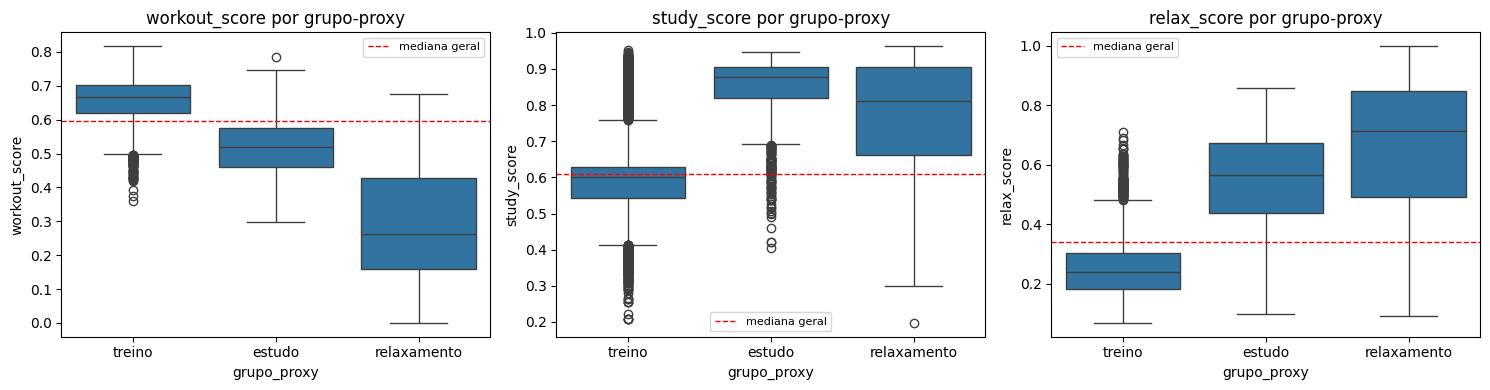

In [18]:
df_scored = df.copy()
df_scored['grupo_proxy'] = 'resto'
df_scored.loc[df_scored['track_genre'] == 'study', 'grupo_proxy'] = 'estudo'
df_scored.loc[df_scored['track_genre'] == 'sleep', 'grupo_proxy'] = 'relaxamento'
df_scored.loc[df_scored['track_genre'].isin(['edm','techno','hardstyle','dance','party']), 'grupo_proxy'] = 'treino'

subset = df_scored[df_scored['grupo_proxy'] != 'resto']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (score, grupo_alvo) in zip(axes, [('workout_score','treino'),('study_score','estudo'),('relax_score','relaxamento')]):
    sns.boxplot(data=subset, x='grupo_proxy', y=score, ax=ax,
                order=['treino','estudo','relaxamento'])
    ax.axhline(df[score].median(), color='red', linestyle='--', linewidth=1, label='mediana geral')
    ax.set_title(f"{score} por grupo-proxy")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("fig_scores_por_grupo.png", dpi=110)
plt.show()


## 10. Estratégia de rotulagem e dados de usuários

O Spotify Dataset não contém a verdade de referência necessária para afirmar que uma música é adequada a uma atividade para uma pessoa real.

Por isso, a investigação prevê uma pesquisa com usuários para avaliar:
- mudança de preferência entre Treino, Estudo, Relaxamento e Trabalho;
- diferenças de preferência conforme o tipo de trabalho;
- percepção de adequação de recomendações contextuais.

### Status
- **PF-10 — formulário:** concluída.
- **PF-11 — coleta:** em andamento/conforme número de respostas disponíveis.
- **PF-12 — análise:** deve ser incorporada aqui quando o CSV/Excel das respostas estiver disponível.

> Nenhum percentual ou resultado de usuário é preenchido nesta seção sem dados reais.


## 11. Baseline

Antes do modelo real, usamos `DummyClassifier` para estabelecer uma referência mínima.

**Correção metodológica da versão integrada:** a divisão treino/teste é feita por **`track_id`**, impedindo que a mesma faixa apareça nos dois conjuntos. Isso reduz risco de vazamento causado por músicas associadas a múltiplos gêneros.


In [19]:
# 11. Baseline — dataset de ML, split por track_id e DummyClassifier

from sklearn.model_selection import GroupShuffleSplit
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

generos_treino = ['edm', 'techno', 'hardstyle', 'dance', 'party']

df_ml = df.copy()

def definir_contexto_proxy(genero):
    if genero in generos_treino:
        return 'Treino'
    elif genero == 'study':
        return 'Estudo'
    elif genero == 'sleep':
        return 'Relaxamento'
    return None

df_ml['contexto_proxy'] = df_ml['track_genre'].apply(definir_contexto_proxy)
df_ml = df_ml[df_ml['contexto_proxy'].notna()].copy()

features_ml = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo'
]

X = df_ml[features_ml].copy()
y = df_ml['contexto_proxy'].copy()
groups = df_ml['track_id'].copy()

print("=== DATASET DO BASELINE ===")
print("Shape:", df_ml.shape)
print("\nDistribuição das classes:")
print(y.value_counts())

# Split agrupado: a mesma track_id não pode aparecer em treino e teste.
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

track_train = set(groups.iloc[train_idx])
track_test = set(groups.iloc[test_idx])
sobreposicao_tracks = track_train.intersection(track_test)

assert len(sobreposicao_tracks) == 0, (
    "Vazamento detectado: há track_id em treino e teste."
)

print("\nTreino:", X_train.shape)
print("Teste:", X_test.shape)
print("Track IDs compartilhadas entre treino/teste:", len(sobreposicao_tracks))
print("\nDistribuição no teste:")
print(y_test.value_counts())

baselines = {
    'Most Frequent': DummyClassifier(
        strategy='most_frequent',
        random_state=42
    ),
    'Stratified': DummyClassifier(
        strategy='stratified',
        random_state=42
    )
}

resultados_baseline = []

for nome, modelo in baselines.items():
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)

    resultados_baseline.append({
        'modelo': nome,
        'accuracy': accuracy_score(y_test, pred),
        'macro_f1': f1_score(y_test, pred, average='macro')
    })

tabela_baseline = pd.DataFrame(resultados_baseline).sort_values(
    'macro_f1',
    ascending=False
).reset_index(drop=True)

print("\n=== RESULTADOS DO BASELINE ===")
display(tabela_baseline.style.format({
    'accuracy': '{:.4f}',
    'macro_f1': '{:.4f}'
}))

baseline_macro_f1 = tabela_baseline['macro_f1'].max()
print(f"\nMelhor Macro F1 entre os baselines: {baseline_macro_f1:.4f}")


=== DATASET DO BASELINE ===
Shape: (6948, 28)

Distribuição das classes:
contexto_proxy
Treino         4950
Relaxamento    1000
Estudo          998
Name: count, dtype: int64

Treino: (5560, 9)
Teste: (1388, 9)
Track IDs compartilhadas entre treino/teste: 0

Distribuição no teste:
contexto_proxy
Treino         986
Estudo         202
Relaxamento    200
Name: count, dtype: int64

=== RESULTADOS DO BASELINE ===


,modelo,accuracy,macro_f1
0,Stratified,0.5346,0.3155
1,Most Frequent,0.7104,0.2769



Melhor Macro F1 entre os baselines: 0.3155


In [20]:
# 11.1 Relatório do baseline determinístico

baseline_ref = DummyClassifier(
    strategy='most_frequent',
    random_state=42
)

baseline_ref.fit(X_train, y_train)
pred_ref = baseline_ref.predict(X_test)

print("=== CLASSIFICATION REPORT — MOST FREQUENT ===")
print(classification_report(
    y_test,
    pred_ref,
    zero_division=0
))

classes_ordem = ['Treino', 'Estudo', 'Relaxamento']

cm = confusion_matrix(
    y_test,
    pred_ref,
    labels=classes_ordem
)

cm_df = pd.DataFrame(
    cm,
    index=[f"Real: {c}" for c in classes_ordem],
    columns=[f"Prev: {c}" for c in classes_ordem]
)

display(cm_df)


=== CLASSIFICATION REPORT — MOST FREQUENT ===
              precision    recall  f1-score   support

      Estudo       0.00      0.00      0.00       202
 Relaxamento       0.00      0.00      0.00       200
      Treino       0.71      1.00      0.83       986

    accuracy                           0.71      1388
   macro avg       0.24      0.33      0.28      1388
weighted avg       0.50      0.71      0.59      1388



,Prev: Treino,Prev: Estudo,Prev: Relaxamento
Real: Treino,986,0,0
Real: Estudo,202,0,0
Real: Relaxamento,200,0,0


## 12. Modelagem de Machine Learning

O primeiro modelo é uma **Regressão Logística** com:
- padronização via `StandardScaler`;
- `class_weight='balanced'`;
- as mesmas features sonoras utilizadas no baseline;
- o mesmo split agrupado por `track_id`.

`track_genre` é usado somente para formar o rótulo-proxy e **não entra como feature**.


In [21]:
# 12. Modelagem — Regressão Logística

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

modelo_logistico = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        max_iter=3000,
        class_weight='balanced',
        random_state=42
    ))
])

modelo_logistico.fit(X_train, y_train)
pred_logistico = modelo_logistico.predict(X_test)

accuracy_logistico = accuracy_score(y_test, pred_logistico)
macro_f1_logistico = f1_score(
    y_test,
    pred_logistico,
    average='macro'
)

ganho_absoluto = macro_f1_logistico - baseline_macro_f1
ganho_percentual = (
    ganho_absoluto / baseline_macro_f1 * 100
    if baseline_macro_f1 > 0
    else float('nan')
)

print("=== REGRESSÃO LOGÍSTICA ===")
print(f"Accuracy: {accuracy_logistico:.4f}")
print(f"Macro F1: {macro_f1_logistico:.4f}")
print(f"Melhor baseline Macro F1: {baseline_macro_f1:.4f}")
print(f"Ganho absoluto: {ganho_absoluto:+.4f}")
print(f"Ganho percentual: {ganho_percentual:+.2f}%")

if macro_f1_logistico > baseline_macro_f1:
    print("\n✓ O modelo SUPEROU o baseline.")
else:
    print("\n✗ O modelo NÃO superou o baseline.")


=== REGRESSÃO LOGÍSTICA ===
Accuracy: 0.9553
Macro F1: 0.9413
Melhor baseline Macro F1: 0.3155
Ganho absoluto: +0.6258
Ganho percentual: +198.35%

✓ O modelo SUPEROU o baseline.


In [22]:
# PF-14 — Interpretação dos coeficientes do modelo

modelo_lr = modelo_logistico.named_steps['model']

coeficientes = pd.DataFrame(
    modelo_lr.coef_,
    index=modelo_lr.classes_,
    columns=features_ml
)

print("=== COEFICIENTES PADRONIZADOS POR CLASSE ===")
display(coeficientes.round(3))

# Top features positivas para cada classe
for classe in coeficientes.index:
    top = coeficientes.loc[classe].sort_values(
        ascending=False
    ).head(5)

    print(f"\nTop features associadas a {classe}:")
    for feature, valor in top.items():
        print(f"  {feature}: {valor:.3f}")


=== COEFICIENTES PADRONIZADOS POR CLASSE ===


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
Estudo,1.803,-1.360,1.692,0.605,0.097,1.547,-0.139,0.414,-0.273
Relaxamento,-4.156,-0.023,-2.542,-0.610,1.266,-0.407,0.831,0.258,-0.044
Treino,2.353,1.383,0.850,0.005,-1.363,-1.140,-0.692,-0.672,0.317



Top features associadas a Estudo:
  danceability: 1.803
  loudness: 1.692
  instrumentalness: 1.547
  speechiness: 0.605
  valence: 0.414

Top features associadas a Relaxamento:
  acousticness: 1.266
  liveness: 0.831
  valence: 0.258
  energy: -0.023
  tempo: -0.044

Top features associadas a Treino:
  danceability: 2.353
  energy: 1.383
  loudness: 0.850
  tempo: 0.317
  speechiness: 0.005


## 13. Avaliação

A avaliação compara o modelo com o baseline usando **Macro F1** como métrica principal, além de Accuracy, Precision, Recall, F1 por classe e matriz de confusão.


In [23]:
# 13. Avaliação detalhada por classe

print("=== CLASSIFICATION REPORT — REGRESSÃO LOGÍSTICA ===")
print(classification_report(
    y_test,
    pred_logistico,
    zero_division=0
))

classes_avaliacao = ['Treino', 'Estudo', 'Relaxamento']

cm_logistico = confusion_matrix(
    y_test,
    pred_logistico,
    labels=classes_avaliacao
)

cm_logistico_df = pd.DataFrame(
    cm_logistico,
    index=[f"Real: {c}" for c in classes_avaliacao],
    columns=[f"Prev: {c}" for c in classes_avaliacao]
)

display(cm_logistico_df)


=== CLASSIFICATION REPORT — REGRESSÃO LOGÍSTICA ===
              precision    recall  f1-score   support

      Estudo       0.79      0.95      0.86       202
 Relaxamento       0.99      0.98      0.99       200
      Treino       0.99      0.95      0.97       986

    accuracy                           0.96      1388
   macro avg       0.93      0.96      0.94      1388
weighted avg       0.96      0.96      0.96      1388



,Prev: Treino,Prev: Estudo,Prev: Relaxamento
Real: Treino,937,48,1
Real: Estudo,10,192,0
Real: Relaxamento,1,2,197


In [24]:
# 13.1 Consolidação das métricas finais

from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    y_test,
    pred_logistico,
    labels=classes_avaliacao,
    zero_division=0
)

metricas_por_classe = pd.DataFrame({
    'classe': classes_avaliacao,
    'precision': precision,
    'recall': recall,
    'f1_score': f1,
    'support': support
})

resumo_final_modelo = pd.DataFrame({
    'modelo': ['Melhor baseline', 'Regressão Logística'],
    'accuracy': [
        tabela_baseline.loc[
            tabela_baseline['macro_f1'].idxmax(),
            'accuracy'
        ],
        accuracy_logistico
    ],
    'macro_f1': [
        baseline_macro_f1,
        macro_f1_logistico
    ]
})

print("=== MÉTRICAS POR CLASSE ===")
display(metricas_por_classe.style.format({
    'precision': '{:.4f}',
    'recall': '{:.4f}',
    'f1_score': '{:.4f}'
}))

print("\n=== COMPARAÇÃO FINAL ===")
display(resumo_final_modelo.style.format({
    'accuracy': '{:.4f}',
    'macro_f1': '{:.4f}'
}))

print(f"\nMacro F1 final do modelo: {macro_f1_logistico:.4f}")
print(f"Macro F1 do melhor baseline: {baseline_macro_f1:.4f}")
print(f"Ganho absoluto: {macro_f1_logistico - baseline_macro_f1:+.4f}")


=== MÉTRICAS POR CLASSE ===


,classe,precision,recall,f1_score,support
0,Treino,0.9884,0.9503,0.9690,986
1,Estudo,0.7934,0.9505,0.8649,202
2,Relaxamento,0.9949,0.9850,0.9899,200



=== COMPARAÇÃO FINAL ===


,modelo,accuracy,macro_f1
0,Melhor baseline,0.5346,0.3155
1,Regressão Logística,0.9553,0.9413



Macro F1 final do modelo: 0.9413
Macro F1 do melhor baseline: 0.3155
Ganho absoluto: +0.6258


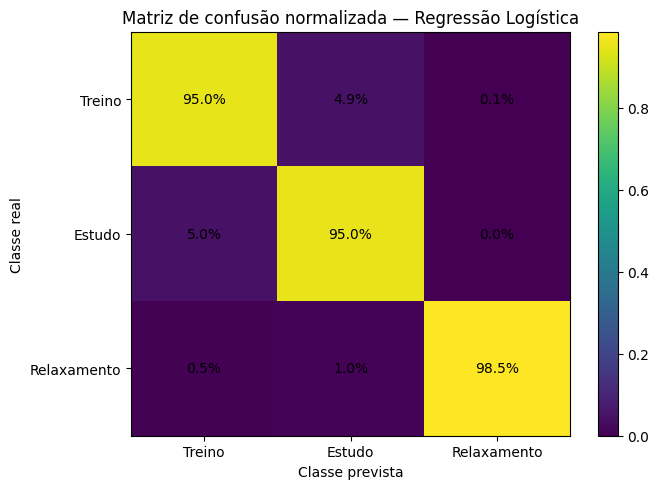

In [25]:
# 13.2 Matriz de confusão normalizada

cm_norm = confusion_matrix(
    y_test,
    pred_logistico,
    labels=classes_avaliacao,
    normalize='true'
)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cm_norm, aspect='auto')

ax.set_xticks(range(len(classes_avaliacao)))
ax.set_yticks(range(len(classes_avaliacao)))
ax.set_xticklabels(classes_avaliacao)
ax.set_yticklabels(classes_avaliacao)
ax.set_xlabel("Classe prevista")
ax.set_ylabel("Classe real")
ax.set_title("Matriz de confusão normalizada — Regressão Logística")

for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        ax.text(
            j, i, f"{cm_norm[i, j]:.1%}",
            ha='center', va='center'
        )

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig("fig_matriz_confusao_normalizada.png", dpi=200)
plt.show()


In [26]:
# 13.3 Critérios de aceitação da prova inicial

criterios_modelo = {
    'Supera baseline em Macro F1':
        macro_f1_logistico > baseline_macro_f1,
    'Macro F1 acima de 0.70':
        macro_f1_logistico >= 0.70,
    'Todas as classes com F1 acima de 0.70':
        (metricas_por_classe['f1_score'] >= 0.70).all(),
    'Sem track_id compartilhada entre treino e teste':
        len(sobreposicao_tracks) == 0
}

print("=== CRITÉRIOS DE ACEITAÇÃO ===")
for criterio, aprovado in criterios_modelo.items():
    status = "✓ APROVADO" if aprovado else "✗ NÃO APROVADO"
    print(f"{status} — {criterio}")

modelo_aprovado = all(criterios_modelo.values())

print(
    "\nResultado:",
    "MODELO APROVADO PARA A PROVA INICIAL"
    if modelo_aprovado
    else "MODELO PRECISA DE REVISÃO"
)


=== CRITÉRIOS DE ACEITAÇÃO ===
✓ APROVADO — Supera baseline em Macro F1
✓ APROVADO — Macro F1 acima de 0.70
✓ APROVADO — Todas as classes com F1 acima de 0.70
✓ APROVADO — Sem track_id compartilhada entre treino e teste

Resultado: MODELO APROVADO PARA A PROVA INICIAL


## 14. Experimento de recomendação

### Status: pendente de execução com usuários

Para testar H6 de maneira compatível com o objetivo de negócio, a etapa recomendada é comparar:

- **Condição A:** seleção/recomendação aleatória ou baseline;
- **Condição B:** recomendação contextual PulseFlow.

Métrica principal sugerida:
- adequação percebida ao contexto.

Métricas secundárias:
- preferência A/B;
- rejeição/skip;
- intenção de usar a recomendação.

> Esta seção não apresenta resultados enquanto o experimento não for executado. O Macro F1 do classificador mede capacidade de separar proxies e **não substitui** o teste de experiência do usuário.


## 15. Resultados por Guiding Question

### GQ1 — Dados
**Parcialmente respondida.**  
Os testes com proxies mostram evidência para:
- Treino: `energy`, `tempo` e `danceability`;
- Estudo: `instrumentalness`; a expectativa de `speechiness` menor não foi apoiada;
- Relaxamento: `energy`, `tempo` e `acousticness`.

O contexto Trabalho ainda depende da pesquisa com usuários.

### GQ2 — Usuário
**Pendente da PF-12.**  
Não pode ser respondida pelo Spotify Dataset, pois ele não contém preferências da mesma pessoa em atividades diferentes.

### GQ3 — Trabalho
**Pendente da PF-12.**  
O dataset não informa tipo de trabalho nem adequação percebida por profissão/atividade.

### GQ4 — Smartwatch
**Não testada nesta etapa.**  
Permanece como visão futura e não deve ser apresentada como funcionalidade validada.

### GQ5 — Machine Learning
**Parcialmente respondida.**  
O classificador é comparado com DummyClassifier usando proxies e split agrupado por `track_id`. Se superar o baseline, isso sustenta viabilidade técnica de classificação dos proxies — não adequação humana comprovada.

### GQ6 — Ética
**Resposta conceitual inicial.**  
O MVP deve priorizar dados mínimos necessários, contexto declarado/autorizado e evitar inferências clínicas ou coleta invasiva.


## 16. Recomendações baseadas nas evidências atuais

### Manter como candidatas no MVP
- **Treino:** `energy`, `tempo`, `danceability`.
- **Estudo:** `instrumentalness`.
- **Relaxamento:** `energy`, `tempo`, `acousticness`.
- classificação baseada em características musicais como prova técnica inicial.

### Não transformar em regra ainda
- `speechiness` baixa para Estudo;
- perfil único de Trabalho;
- automação por smartwatch;
- detecção automática de conversa;
- qualquer score heurístico como “verdade” sobre o usuário.

### Decisão de produto
O PulseFlow deve evoluir como sistema **contextual e personalizável**, usando o dataset para gerar candidatos e a pesquisa/feedback humano para validar adequação real.


## 17. Limitações, ética e próximos passos

### Limitações
- `track_genre` é proxy de contexto, não rótulo de preferência humana.
- O excelente desempenho de ML pode refletir separação entre gêneros escolhidos como proxies; não prova recomendação contextual real.
- Os scores derivados são heurísticos.
- O split de ML foi corrigido para impedir a mesma `track_id` em treino e teste, mas ainda existe dependência da definição dos proxies.
- Trabalho ainda não possui rótulo validado.
- Pesquisa com usuários e experimento A/B ainda precisam ser incorporados.
- A licença/origem formal do dataset deve ser confirmada para a entrega.

### Ética
- coletar somente dados necessários ao objetivo;
- explicitar finalidade da coleta;
- evitar diagnóstico médico ou inferências clínicas;
- não usar localização/sensores de forma invasiva;
- em contextos críticos, priorizar confirmação do usuário e estabilidade.

### Próximos passos
1. finalizar PF-11 — coleta;
2. executar PF-12 — análise das respostas;
3. executar o experimento de recomendação;
4. PF-17 — fechar respostas oficiais das GQs com evidências;
5. PF-18 — apresentação final;
6. PF-19 — revisão geral e `Run All`;
7. PF-20 — ensaio e entrega.
